In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## matplotlib-seaborn fundamentals

In [4]:
plt.figure(figsize = (12,8))
# başlangıçta bir çerçeve belirliyoruz 
#figsize fonksiyonu ile çerçevenin ne kadar olacağını belirliyoruz.
plt.show() 
# buradaki show fonksiyonu göstermek anlamına gelir ve oluşturduğumuz çerçevenin boyutlarını görmüş olduk.

<Figure size 1200x800 with 0 Axes>

### plt.plot fonksiyonu

<Figure size 400x400 with 0 Axes>

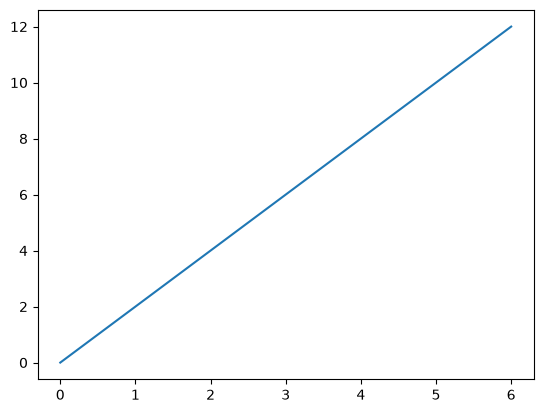

<Figure size 400x400 with 0 Axes>

In [13]:
x = [0,1,2,3,4,5,6]
y = [0,2,4,6,8,10,12]
plt.plot(x,y)
# x ve y ekseni değerlerini belirledik.
# burda fonksiyon f(x) = 2x
plt.figure(figsize = (4,4))
#fig size ile grafiğin ölçeğini ayarlayabiliyoruz.

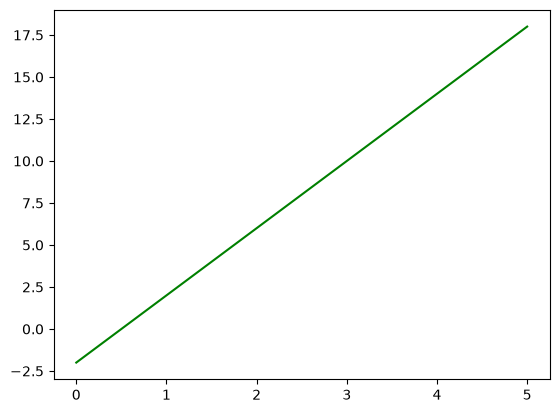

In [17]:
x = np.arange(6)
y = 4*x -2
plt.plot(x,y,'g')

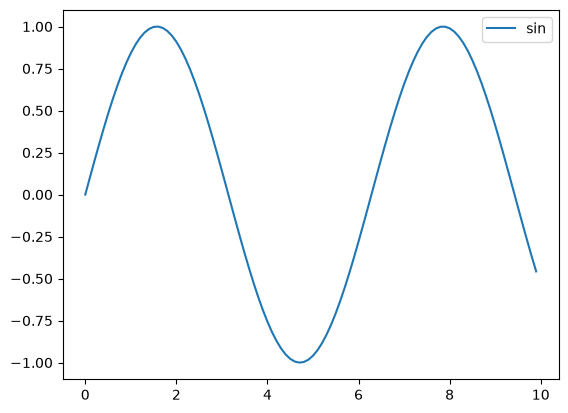

In [22]:
x = np.arange(100) / 10
y = np.sin(x)
plt.plot(x,y , label = 'sin')
plt.legend()
#plot fonskiyonunda label vererek iç başlık oluşturabiliyoruz.
#legend fonskiyonu ile de gösterebiliyoruz.

### plt.scatter

In [23]:
# plot noktaları birleştiriyor.
# scatter ise o noktalra gelen uygun yerleri kesikli noktalar halinde işaretler.

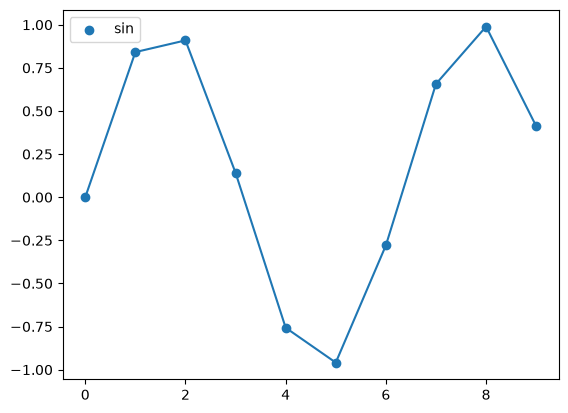

In [31]:
x = np.arange(10)
y = np.sin(x)
plt.plot(x,y)
plt.scatter(x,y , label = 'sin')
plt.legend()
# plot ve scatteri aynı anda kullanabiliriz.
# color(rengini) , linestyle(çizgi stilini) , marker(noktalara denk gelen kesişimleri),alpha(saydamlık-opaklık) gibi parametreleri bulunur.
#label = grafiğin etiketi

### sahte veri oluşturma

In [35]:
data = {
    'yıl': np.arange(2010,2021),
    'satış': np.random.randint(100,500,11),
    'masraf': np.random.randint(50,400,11)
}
df = pd.DataFrame(data)
yönler = ['kuzey','güney','doğu','batı']
df['yönler']=np.random.choice(['kuzey','güney','doğu','batı'],df.shape[0])
df

,yıl,satış,masraf,yönler
0,2010,312,326,doğu
1,2011,145,196,güney
2,2012,371,355,batı
3,2013,405,283,doğu
4,2014,295,129,kuzey
5,2015,303,238,batı
6,2016,108,213,doğu
7,2017,413,218,batı
8,2018,271,156,güney
9,2019,403,203,batı


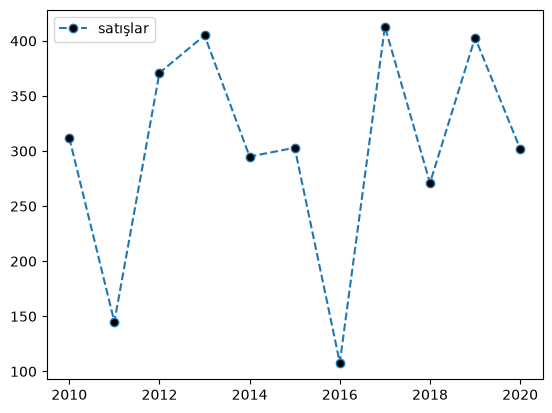

In [38]:
plt.plot(df['yıl'],df['satış'],label='satışlar',linestyle='--',marker = 'o',markerfacecolor='black')
plt.legend()

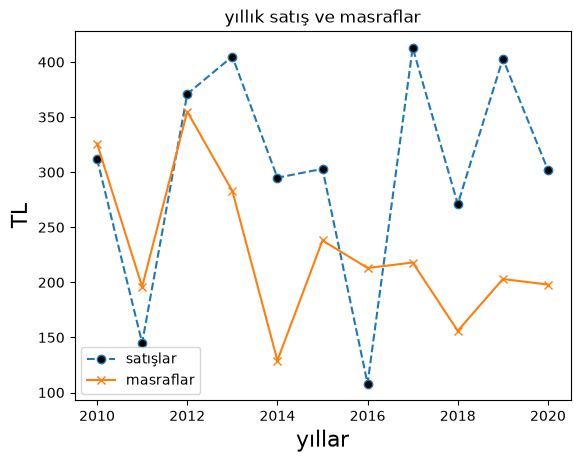

In [45]:
plt.plot(df['yıl'],df['satış'],label='satışlar',linestyle='--',marker = 'o',markerfacecolor='black')
plt.plot(df['yıl'],df['masraf'],label='masraflar',linestyle='-',marker='x',markerfacecolor='black')
plt.title('yıllık satış ve masraflar')
plt.xlabel('yıllar',fontsize=16)
plt.ylabel('TL',fontsize=16)
plt.legend()
plt.show()

### plt.bar()
-- plt.bar() bir stün grafiği çizer , bu grafik türü farklı kategorilerin değerleri arasındaki ilişkiyi gösterir.

### parametreler
'color': stünların rengini belirtir.

'width: stünların genişliğini kontrol eder.'

'edgecolor: stünların kenarlık rengini belirler.'

'linewidth: kenarlık kalınlığını belirtir.'

<BarContainer object of 5 artists>

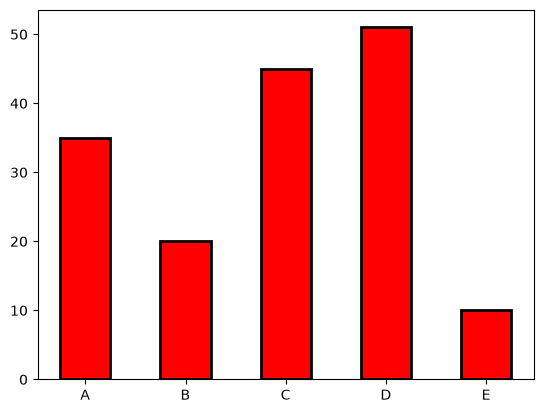

In [47]:
categories = ['A','B','C','D','E']
values = [35,20,45,51,10]
plt.bar(categories,values,color='red',width=0.5,edgecolor='black',linewidth=2)

<BarContainer object of 5 artists>

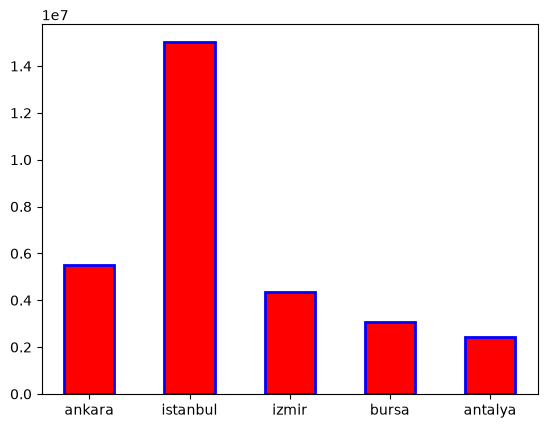

In [51]:
data_dict= { 'şehir': ['ankara','istanbul','izmir','bursa','antalya'],
         'nüfus': [5503985,15029231,4367251,3056120,2444535]}

plt.bar(data_dict['şehir'],data['nüfus'],color='red',width = 0.5 , edgecolor= 'blue',linewidth=2)

# sceintific notatin ile 1e7 yazıyor yani 7 tane sıfır var, otomatik formatladı.

In [57]:
sales_by_region = df.groupby('yönler')['satış'].sum()
sales_by_region

yönler
batı     1490
doğu      825
güney     718
kuzey     295
Name: satış, dtype: int32

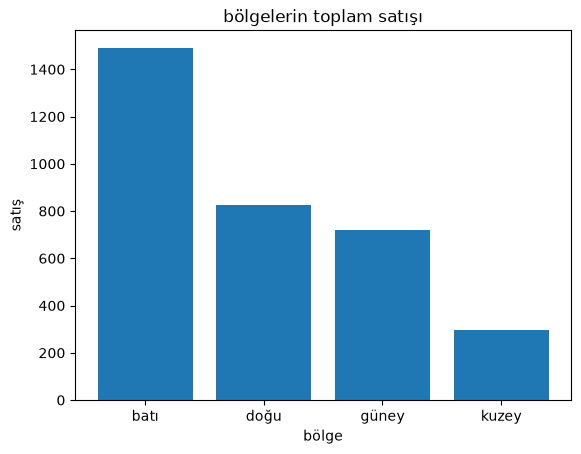

In [64]:
plt.bar(sales_by_region.index,sales_by_region.values)
plt.xlabel('bölge')
plt.ylabel('satış')
plt.title('bölgelerin toplam satışı')
plt.show()

In [65]:
df

,yıl,satış,masraf,yönler
0,2010,312,326,doğu
1,2011,145,196,güney
2,2012,371,355,batı
3,2013,405,283,doğu
4,2014,295,129,kuzey
5,2015,303,238,batı
6,2016,108,213,doğu
7,2017,413,218,batı
8,2018,271,156,güney
9,2019,403,203,batı


### histogram mantığı

In [78]:
sales_bins = pd.qcut(df['satış'],q=10)
#iki fonksiyon var. pd.cut ve pd.qcut
# pandas cut = bin arası mesafe eşit.
# pandas qcut = bin arası mesafe eşit değil.
#(114-99) örneğin bir bin'i ifade eder.
bin_counts = sales_bins.value_counts()
# yani burada qcut kullanara kendi nümerik verimizi belli kategoriler arasında belirlemeyi başardık.
bin_counts

satış
(107.999, 145.0]    2
(145.0, 271.0]      1
(271.0, 295.0]      1
(295.0, 302.0]      1
(302.0, 303.0]      1
(303.0, 312.0]      1
(312.0, 371.0]      1
(371.0, 403.0]      1
(403.0, 405.0]      1
(405.0, 413.0]      1
Name: count, dtype: int64

In [79]:
bin_counts.index

CategoricalIndex([(107.999, 145.0],   (145.0, 271.0],   (271.0, 295.0],
                    (295.0, 302.0],   (302.0, 303.0],   (303.0, 312.0],
                    (312.0, 371.0],   (371.0, 403.0],   (403.0, 405.0],
                    (405.0, 413.0]],
                 categories=[(107.999, 145.0], (145.0, 271.0], (271.0, 295.0], (295.0, 302.0], ..., (312.0, 371.0], (371.0, 403.0], (403.0, 405.0], (405.0, 413.0]], ordered=True, dtype='category', name='satış')

In [82]:
bin_middles = [(interval.left + interval.right) / 2 for interval in bin_counts.index]
bin_middles
# binlerdeki aralığın orta değerini aldık.

[np.float64(126.4995),
 np.float64(208.0),
 np.float64(283.0),
 np.float64(298.5),
 np.float64(302.5),
 np.float64(307.5),
 np.float64(341.5),
 np.float64(387.0),
 np.float64(404.0),
 np.float64(409.0)]

<BarContainer object of 10 artists>

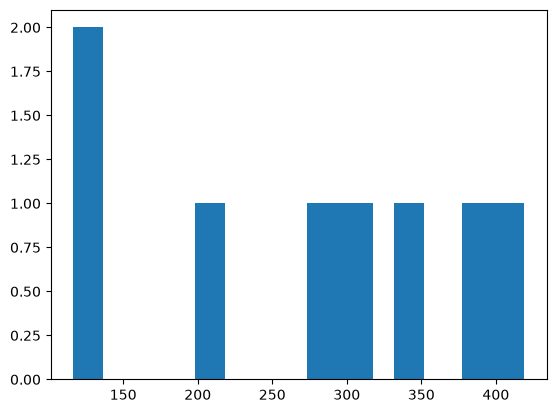

In [83]:
plt.bar(bin_middles,
       bin_counts.values,
       width = 20)

### plt.hist()
- Nümerik değerlerimizin dağılımını yorumlamamızı sağlayan bir grafiktir,histogram çizer.
### parametreler
- bins = grup sayısını belirler
- range = binlerin alt ve üst limitini belirler
- density = true olursa grafik yoğunluk belirtir false olursa frekans
- color = bin rengi
- alpha = saydamlık opaklık

(array([1., 1., 0., 0., 0., 1., 4., 0., 1., 3.]),
 array([108. , 138.5, 169. , 199.5, 230. , 260.5, 291. , 321.5, 352. ,
        382.5, 413. ]),
 <BarContainer object of 10 artists>)

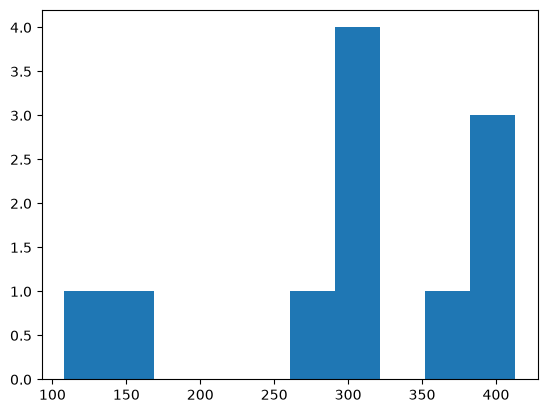

In [85]:
plt.hist(df['satış'],bins=10)

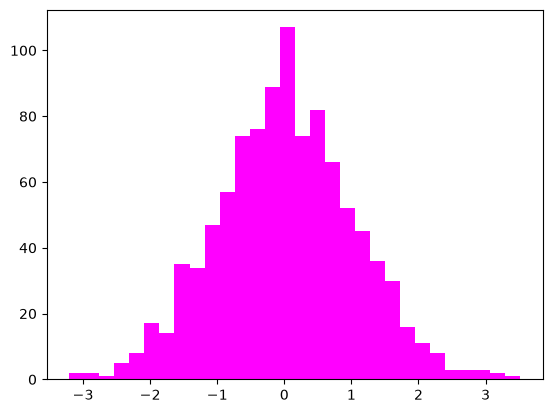

In [86]:
data_normal = np.random.randn(1000)
plt.hist(data_normal,bins=30, color='magenta')
plt.show()

In [18]:
# x ve y ekseninde bulunan değer sayılarının bouytunu default olarak değiştirdik.
plt.rcParams['xtick.labelsize'] = 14 
plt.rcParams['ytick.labelsize'] = 14
# eksen label boyutunu değiştirdik.
plt.rcParams['axes.labelsize'] = 16
#burda default olarak atanan değerleri görüp değiştirebiliyoruz.


### Seaborn

In [9]:
data1 = sns.load_dataset('penguins')
data1

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


<Axes: xlabel='flipper_length_mm', ylabel='Count'>

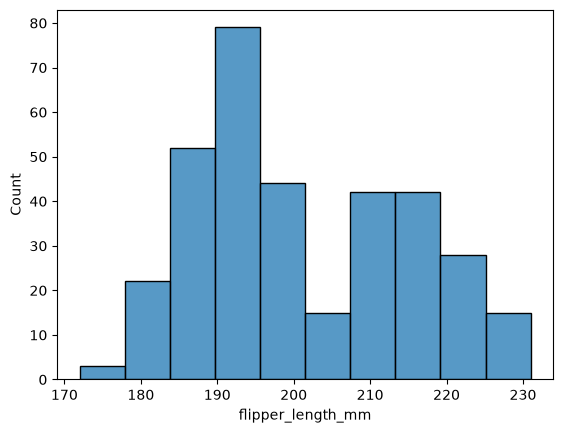

In [14]:
sns.histplot(data=data1,x='flipper_length_mm')

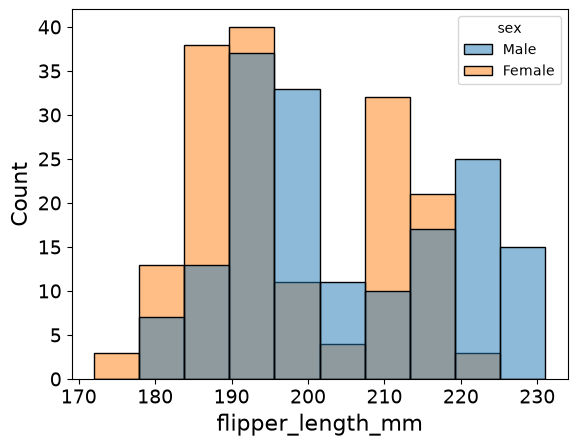

In [19]:
# seaborn ile histogram
sns.histplot(data=data1, x='flipper_length_mm', hue='sex',alpha=0.5)
plt.show()

## seaborn ile scatterplot

In [21]:
data1

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Text(0.5, 1.0, 'bill_length vs bill_depth')

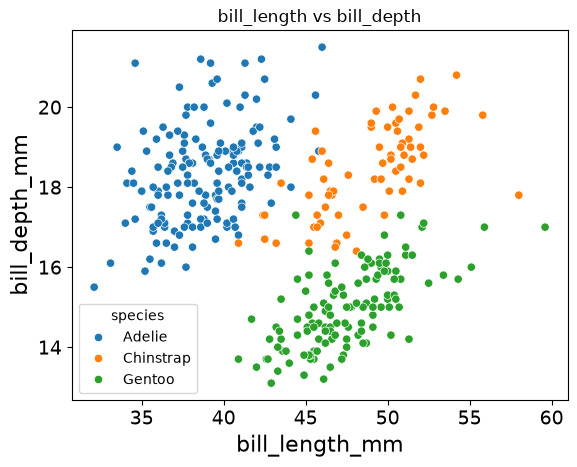

In [23]:
sns.scatterplot(
    data = data1,
    x = 'bill_length_mm',
    y = 'bill_depth_mm',
    hue = 'species',
)
plt.title('bill_length vs bill_depth')

### Seaborn ile barplot

In [27]:
grouped_data = data1.groupby(['species','sex'])['body_mass_g'].mean().reset_index()

<Axes: xlabel='species', ylabel='body_mass_g'>

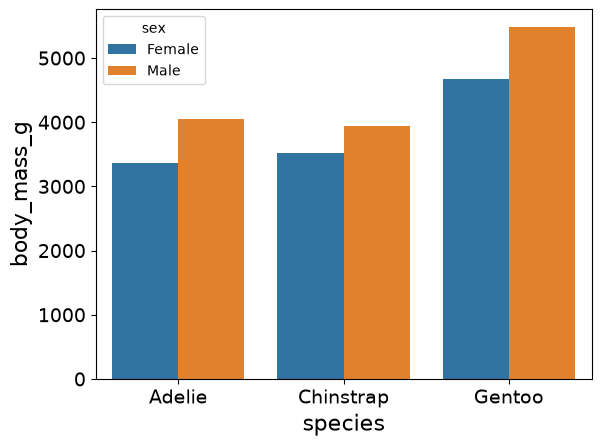

In [29]:
sns.barplot(data = grouped_data, x='species',y='body_mass_g',hue='sex')

### Subplot oluşturma

<Axes: xlabel='bill_length_mm', ylabel='Count'>

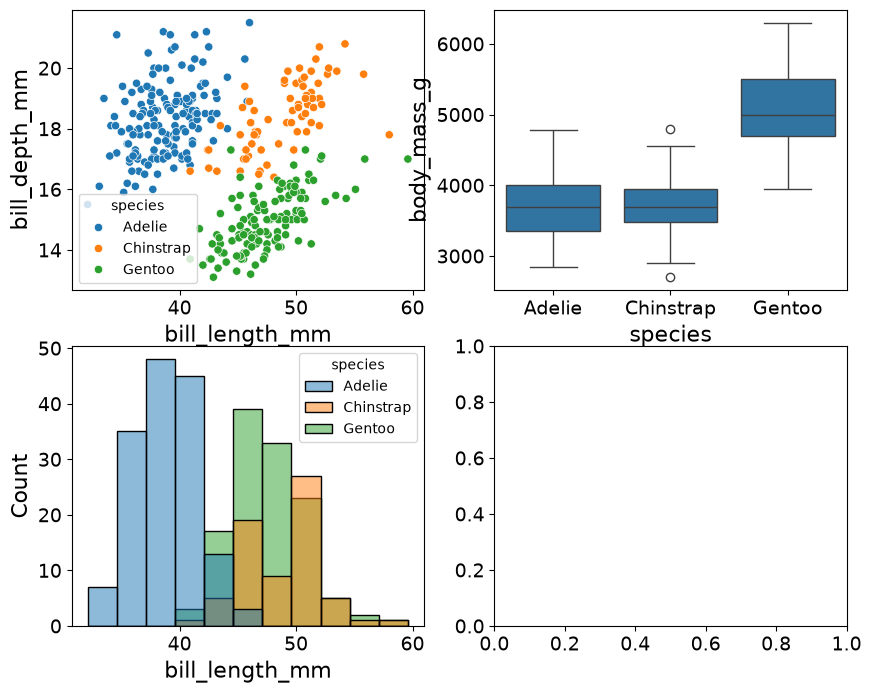

In [48]:


#subplot ile bir figure'nin içine farklı plotlar koyabiliriz.
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
sns.scatterplot(
    data = data1,
    x = 'bill_length_mm',
    y = 'bill_depth_mm',
    hue = 'species',
    ax=axes[0,0]
)
sns.boxplot(
    data=data1,
    x = 'species',
    y='body_mass_g',
    ax=axes[0,1]
)
sns.histplot(
    data=data1,
    x = 'bill_length_mm',
    ax=axes[1,0],
    hue = 'species'
)


### colormap ekleme

In [53]:
grouped_data = data1.groupby(['species'])['body_mass_g'].mean().reset_index()
grouped_data

,species,body_mass_g
0,Adelie,3700.662252
1,Chinstrap,3733.088235
2,Gentoo,5076.016260


<Axes: xlabel='species', ylabel='body_mass_g'>

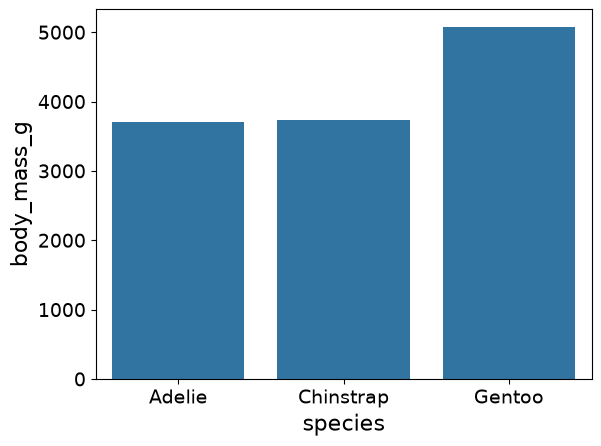

In [60]:


sns.barplot(grouped_data,
            x='species',
            y='body_mass_g'
           )